<a href="https://colab.research.google.com/github/idarwati/Health-Data-Analytics-Portfolio/blob/NLP/NLP_Google_Review_RS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Greview Hospital

In [ ]:

from google.colab import auth
import gspread
from google.auth import default
import pandas as pd

# 1. Minta Izin Akses Google Sheets
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# 2. Buka Google Sheets Anda
# GANTI 'Data_RS_Saya' dengan nama file sheet yang Anda buat tadi
worksheet = gc.open('Data_RS_Saya').sheet1

# 3. Ubah jadi Data Siap Analisis
rows = worksheet.get_all_values()
df = pd.DataFrame.from_records(rows[1:], columns=rows[0])

# Ubah kolom Rating jadi angka
df['Rating'] = pd.to_numeric(df['Rating'])

# Cek hasilnya
df.head()

,Review,Rating,Kategori
0,"Keren, ramah pelayanannya",5,
1,"Pelayanan terbaik , terima ksih staf Andi Fati...",5,
2,Sangat Baik,5,
3,Security sangat membantu apalagi pasien lansia...,5,
4,"Sangat bagus, security sangat bagus bantu seka...",5,


/tmp/ipython-input-1568763727.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Kategori_Isu', data=df, palette='Reds')


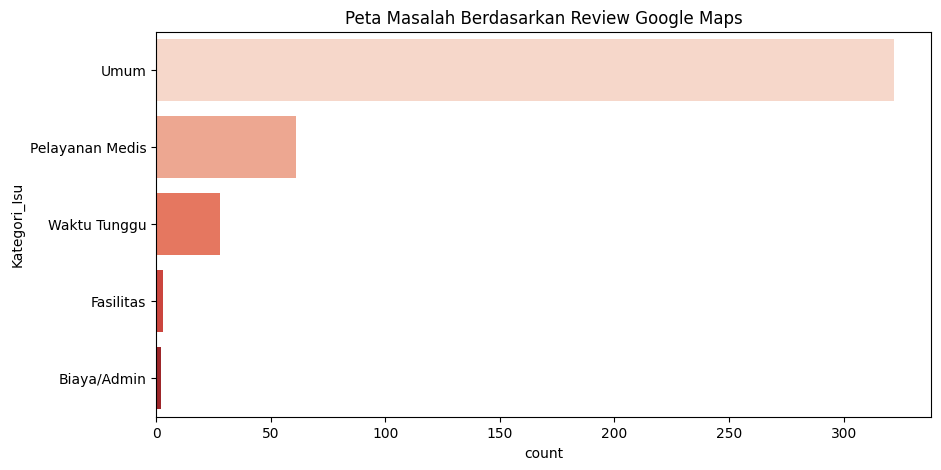

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fungsi Deteksi Isu Otomatis
def deteksi_isu(teks):
    teks = str(teks).lower()
    if 'antri' in teks or 'lama' in teks or 'nunggu' in teks:
        return 'Waktu Tunggu'
    elif 'dokter' in teks or 'perawat' in teks:
        return 'Pelayanan Medis'
    elif 'kotor' in teks or 'wc' in teks or 'ac' in teks:
        return 'Fasilitas'
    elif 'mahal' in teks or 'bayar' in teks:
        return 'Biaya/Admin'
    else:
        return 'Umum'

# Terapkan
df['Kategori_Isu'] = df['Review'].apply(deteksi_isu)

# Visualisasi
plt.figure(figsize=(10, 5))
sns.countplot(y='Kategori_Isu', data=df, palette='Reds')
plt.title('Peta Masalah Berdasarkan Review Google Maps')
plt.show()

/tmp/ipython-input-7101285.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Kategori_Isu', data=df, palette='Reds')


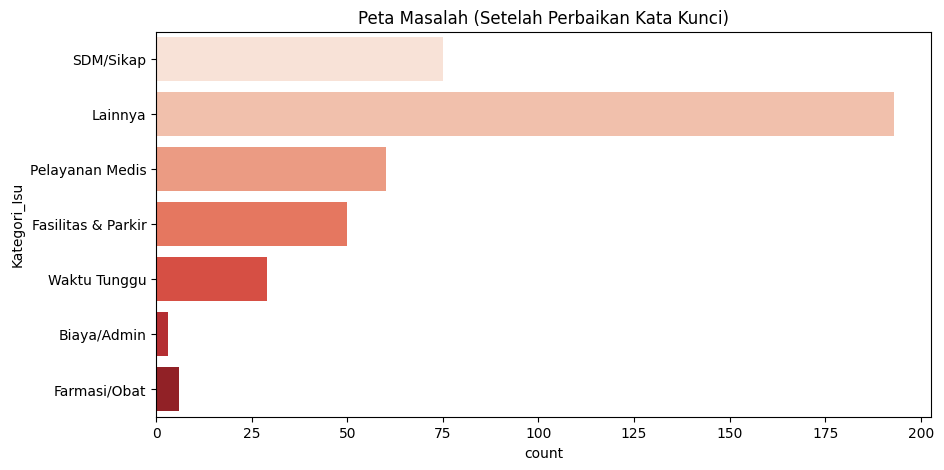

In [ ]:
# Fungsi Deteksi Isu Versi 2 (Lebih Lengkap)
def deteksi_isu(teks):
    teks = str(teks).lower()

    # 1. Masalah Waktu (Ditambah kata: lambat, jam)
    if 'antri' in teks or 'lama' in teks or 'nunggu' in teks or 'lambat' in teks or 'jam' in teks:
        return 'Waktu Tunggu'

    # 2. Medis (Ditambah: bidan, diagnosa)
    elif 'Layanan' in teks or 'dokter' in teks or 'perawat' in teks or 'suster' in teks or 'bidan' in teks:
        return 'Pelayanan Medis'

    # 3. Fasilitas (Ditambah: parkir, panas, bersih)
    elif 'kotor' in teks or 'wc' in teks or 'ac' in teks or 'parkir' in teks or 'panas' in teks or 'bersih' in teks:
        return 'Fasilitas & Parkir'

    # 4. Obat/Farmasi (KATEGORI BARU)
    elif 'obat' in teks or 'resep' in teks or 'apotek' in teks or 'farmasi' in teks:
        return 'Farmasi/Obat'

    # 5. Keamanan/Sikap (KATEGORI BARU)
    elif 'satpam' in teks or 'security' in teks or 'judes' in teks or 'marah' in teks or'ramah' in teks:
        return 'SDM/Sikap'

    # 6. Biaya/Admin
    elif 'mahal' in teks or 'bayar' in teks or 'bpjs' in teks or 'admin' in teks:
        return 'Biaya/Admin'

    else:
        return 'Lainnya'

# Terapkan ulang
df['Kategori_Isu'] = df['Review'].apply(deteksi_isu)

# Visualisasi Ulang
plt.figure(figsize=(10, 5))
sns.countplot(y='Kategori_Isu', data=df, palette='Reds')
plt.title('Peta Masalah (Setelah Perbaikan Kata Kunci)')
plt.show()

/tmp/ipython-input-252243884.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Kategori_Isu',


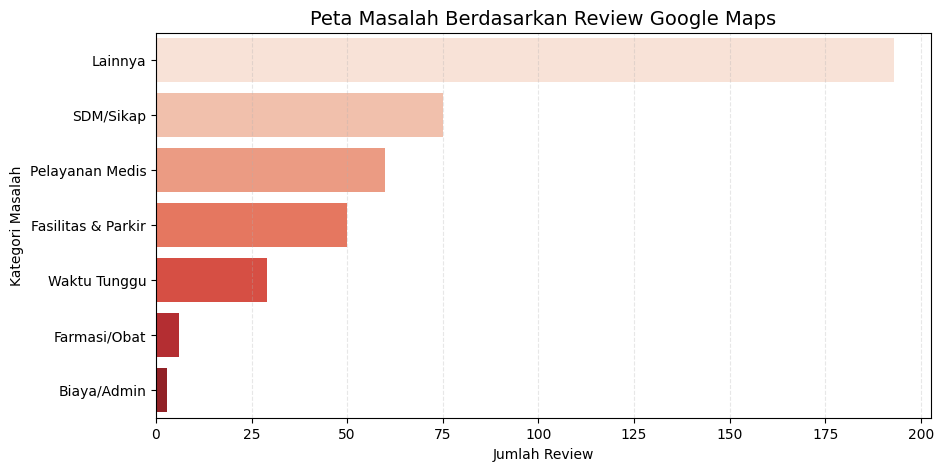

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

# Atur ukuran gambar
plt.figure(figsize=(10, 5))

# Buat Grafik Horizontal
# y = data kategori (agar menyamping)
# palette = 'Reds' (agar warnanya merah pudar ke tua)
sns.countplot(y='Kategori_Isu',
              data=df,
              order=df['Kategori_Isu'].value_counts().index,
              palette='Reds')

plt.title('Peta Masalah Berdasarkan Review Google Maps', fontsize=14)
plt.xlabel('Jumlah Review')
plt.ylabel('Kategori Masalah')
plt.grid(axis='x', linestyle='--', alpha=0.3) # Tambah garis bantu tipis
plt.show()

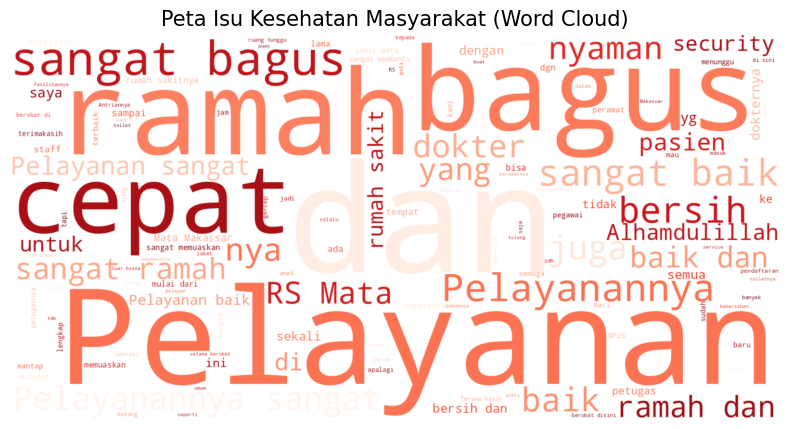

In [ ]:

from wordcloud import WordCloud

# 1. Gabungkan semua review jadi satu teks panjang
text_gabungan = ' '.join(df['Review'].astype(str))

# 2. Buat Word Cloud dengan nuansa Merah
wordcloud = WordCloud(width=1600, height=800,
                      background_color='white', # Latar putih
                      colormap='Reds',          # Teks nuansa merah
                      min_font_size=10).generate(text_gabungan)

# 3. Tampilkan
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off") # Hilangkan garis pinggir
plt.title("Peta Isu Kesehatan Masyarakat (Word Cloud)", fontsize=15)
plt.show()

In [ ]:
def deteksi_isu_servqual_final(teks):
    teks = str(teks).lower()

    # 1. TANGIBLES (Fisik & Fasilitas)
    # Tambahan: parkiran, wc, ruangan, bed, panas, gerah, kumuh, sarana
    keyword_tangibles = ['parkir', 'toilet', 'wc', 'kamar', 'ruang', 'gedung', 'bangunan',
                         'ac', 'panas', 'gerah', 'dingin', 'kotor', 'bersih', 'bau', 'wangi',
                         'kursi', 'rusak', 'kumuh', 'sempit', 'fasilitas', 'kantin', 'mushola',
                         'sarana', 'prasarana', 'nyaman']
    if any(x in teks for x in keyword_tangibles):
        return 'Tangibles (Fisik)'

    # 2. RESPONSIVENESS (Waktu & Kecepatan)
    # Tambahan: ngantri, nunggu, lelet, jam, seharian, lemot
    keyword_responsiveness = ['antri', 'ngantri', 'lama', 'lambat', 'nunggu', 'menunggu',
                              'lelet', 'lemot', 'jam', 'telat', 'ngaret', 'cepat',
                              'segera', 'ditinggal', 'seharian', 'buru']
    if any(x in teks for x in keyword_responsiveness):
        return 'Responsiveness (Waktu)'

    # 3. EMPATHY (Sikap & Pelayanan Orang)
    # Tambahan: security, satpam, dr (singkatan), care, melayani
    keyword_empathy = ['ramah', 'sopan', 'senyum', 'judes', 'galak', 'kasar',
                       'bentak', 'marah', 'cuek', 'sabar', 'suster', 'perawat', 'bidan',
                       'satpam', 'security', 'sekuriti', 'petugas', 'staf', 'pelayanan', 'melayani']
    if any(x in teks for x in keyword_empathy):
        return 'Empathy (Sikap)'

    # 4. ASSURANCE (Kompetensi & Jaminan Mutu) -> UPDATE BESAR DISINI
    # Tambahan: baik, bagus, terbaik, memuaskan, mantap, good
    keyword_assurance = ['dokter', 'dr.', 'dr ', 'ahli', 'profesional', 'kompeten',
                         'jelas', 'paham', 'mengerti', 'tindakan', 'operasi', 'usg',
                         'rontgen', 'lab', 'cek', 'periksa',
                         'bagus', 'mantap', 'terbaik', 'baik', 'ok', 'oke', 'good',
                         'memuaskan', 'puas', 'kecewa', 'parah', 'buruk', 'recom', 'bintang']
    if any(x in teks for x in keyword_assurance):
        return 'Assurance (Kompetensi & Mutu)'

    # 5. RELIABILITY (Prosedur & Admin)
    # Tambahan: ribet, susah, berbelit, daftar, aplikasi, obat
    keyword_reliability = ['obat', 'resep', 'apotek', 'farmasi', 'daftar', 'admin',
                           'registrasi', 'loket', 'bpjs', 'kis', 'bayar', 'biaya', 'kasir',
                           'rujukan', 'sistem', 'aplikasi', 'online', 'jkn', 'ribet',
                           'susah', 'mudah', 'gampang', 'berbelit', 'prosedur', 'alur']
    if any(x in teks for x in keyword_reliability):
        return 'Reliability (Prosedur)'

    return 'Lainnya'

# Terapkan ulang
df['Kategori_Isu'] = df['Review'].apply(deteksi_isu_servqual_final)

# Cek hasilnya lagi
print("--- Distibusi Terbaru (Setelah Update) ---")
print(df['Kategori_Isu'].value_counts())

--- Distibusi Terbaru (Setelah Update) ---
Kategori_Isu
Empathy (Sikap)                  185
Tangibles (Fisik)                114
Responsiveness (Waktu)            52
Assurance (Kompetensi & Mutu)     49
Lainnya                           12
Reliability (Prosedur)             4
Name: count, dtype: int64


In [ ]:
# Tampilkan review yang masih masuk kategori 'Lainnya'
cek_lainnya = df[df['Kategori_Isu'] == 'Lainnya']

# Baca 10 data sampel 'Lainnya'
for i, row in cek_lainnya.head(10).iterrows():
    print(f"- {row['Review']}")

- Excellent work and great service
- Alhamdulillah suka
- helpfull
- Rs Mata Makassar
- Mg bermanfaat bg masyarakat banyak🙏🙏🙏
- stabil
- 🖤
- Mantul
- 👍🏻
- Alhamdulillah ...
Sangat membantu dan terimakasih byk untuk antar jemput nyaaa...
Jazakumullahu khoironil jazaa'


Positif, Negatif, Netral

In [ ]:

def cek_sentimen_final(teks):
    teks = str(teks).lower()

    # --- KAMUS KATA POSITIF ---
    katapos = ['bagus', 'baik', 'mantap', 'terbaik', 'memuaskan', 'puas', 'ok', 'oke',
               'good', 'best', 'ramah', 'sopan', 'senyum', 'bersih', 'nyaman', 'wangi',
               'cepat', 'sigap', 'membantu', 'terima kasih', 'thanks', 'makasih',
               'profesional', 'kompeten', 'ahli', 'jelas', 'paham', 'suka', 'cinta',
               'recom', 'rekomended', 'bintang 5', 'top', 'keren', 'rapi']

    # --- KAMUS KATA NEGATIF ---
    kataneg = ['jelek', 'buruk', 'parah', 'kecewa', 'nyesel', 'kapok', 'lambat', 'lama',
               'lelet', 'lemot', 'antri', 'ngantri', 'nunggu', 'ribet', 'susah', 'sulit',
               'berbelit', 'judes', 'galak', 'marah', 'bentak', 'kasar', 'kotor', 'bau',
               'jorok', 'panas', 'gerah', 'rusak', 'kumuh', 'mahal', 'biaya', 'sakit hati',
               'tidak ramah', 'gak jelas', 'aneh', 'sombong', 'angkuh', 'ditinggal']

    # Hitung skor
    score = 0
    for kata in katapos:
        if kata in teks: score += 1

    for kata in kataneg:
        if kata in teks: score -= 1

    # Tentukan Kesimpulan
    if score > 0:
        return 'Positif'
    elif score < 0:
        return 'Negatif'
    else:
        # Jika tidak ada kata kunci, cek rating bintang (jika ada kolom rating)
        # Asumsi: Jika teks netral tapi rating 5 -> Positif
        return 'Netral'

# Terapkan fungsi ke data
df['Sentimen'] = df['Review'].apply(cek_sentimen_final)

# Cek hasilnya
print("--- Distribusi Sentimen ---")
print(df['Sentimen'].value_counts())

# Tampilkan contoh data agar Anda yakin
display(df[['Review', 'Kategori_Isu', 'Sentimen']].head(10))

--- Distribusi Sentimen ---
Sentimen
Positif    377
Netral      30
Negatif      9
Name: count, dtype: int64


,Review,Kategori_Isu,Sentimen
0,"Keren, ramah pelayanannya",Empathy (Sikap),Positif
1,"Pelayanan terbaik , terima ksih staf Andi Fati...",Empathy (Sikap),Positif
2,Sangat Baik,Assurance (Kompetensi & Mutu),Positif
3,Security sangat membantu apalagi pasien lansia...,Empathy (Sikap),Positif
4,"Sangat bagus, security sangat bagus bantu seka...",Empathy (Sikap),Positif
5,Rumah sakit sangat bagus dan lebih baik kalau ...,Tangibles (Fisik),Positif
6,"Terima kasih rumah sakit mata, alhamdullilah s...",Tangibles (Fisik),Positif
7,"Pelayanannya sangat baik, staff dan security s...",Tangibles (Fisik),Positif
8,Terima kasih untuk security perempuan,Empathy (Sikap),Positif
9,Pelayanan bagus ramah terutama di di loket pen...,Empathy (Sikap),Positif


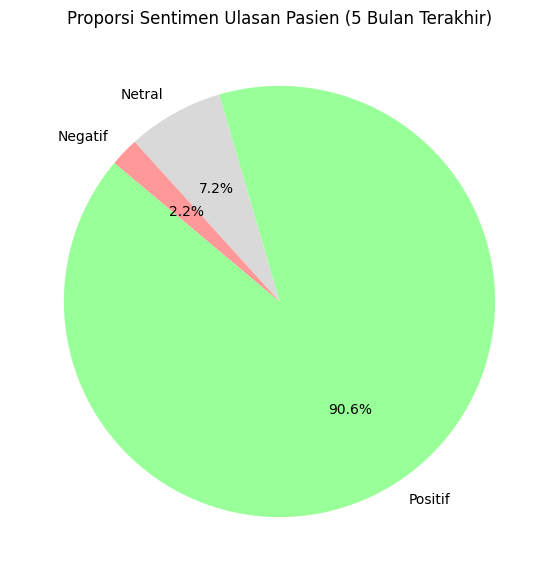

In [ ]:
import matplotlib.pyplot as plt

# Hitung jumlah tiap sentimen
sentimen_counts = df['Sentimen'].value_counts()

# Warna: Hijau (Positif), Merah (Negatif), Abu-abu (Netral)
warna = ['#66b3ff', '#ff9999', '#99ff99'] # Biru, Merah, Hijau muda
if 'Positif' in sentimen_counts and 'Negatif' in sentimen_counts:
    # Atur urutan warna sesuai index data yang muncul
    warna_map = {'Positif': '#99ff99', 'Negatif': '#ff9999', 'Netral': '#d9d9d9'}
    warna = [warna_map[k] for k in sentimen_counts.index]

plt.figure(figsize=(7, 7))
plt.pie(sentimen_counts, labels=sentimen_counts.index, autopct='%1.1f%%', startangle=140, colors=warna)
plt.title('Proporsi Sentimen Ulasan Pasien (5 Bulan Terakhir)')
plt.show()

#Rating

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pastikan rating berupa angka
# Ganti 'Rating' dengan nama kolom rating di Google Sheets Anda jika beda
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Cek apakah ada data rating yang kosong/error
print("Statistik Rating:")
print(df['Rating'].describe())

Statistik Rating:
count    416.000000
mean       4.853365
std        0.673161
min        1.000000
25%        5.000000
50%        5.000000
75%        5.000000
max        5.000000
Name: Rating, dtype: float64


/tmp/ipython-input-344918232.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating', data=df, palette='RdYlGn')


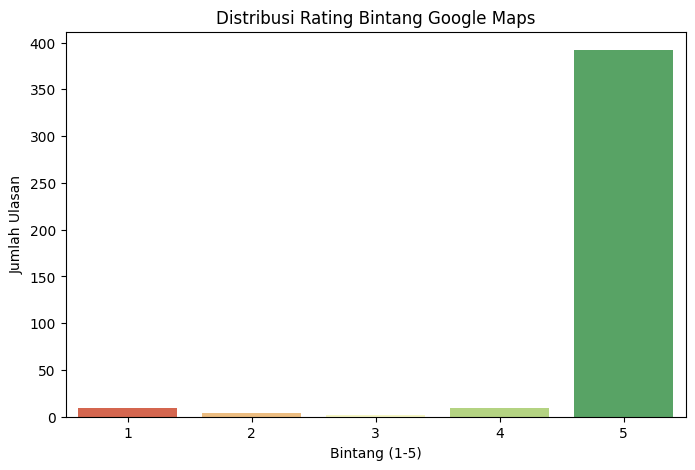

In [ ]:
plt.figure(figsize=(8, 5))
# Palet warna dari Merah (1) ke Hijau (5)
sns.countplot(x='Rating', data=df, palette='RdYlGn')

plt.title('Distribusi Rating Bintang Google Maps')
plt.xlabel('Bintang (1-5)')
plt.ylabel('Jumlah Ulasan')
plt.show()

/tmp/ipython-input-2710554058.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x=avg_rating.values, y=avg_rating.index, palette='coolwarm')


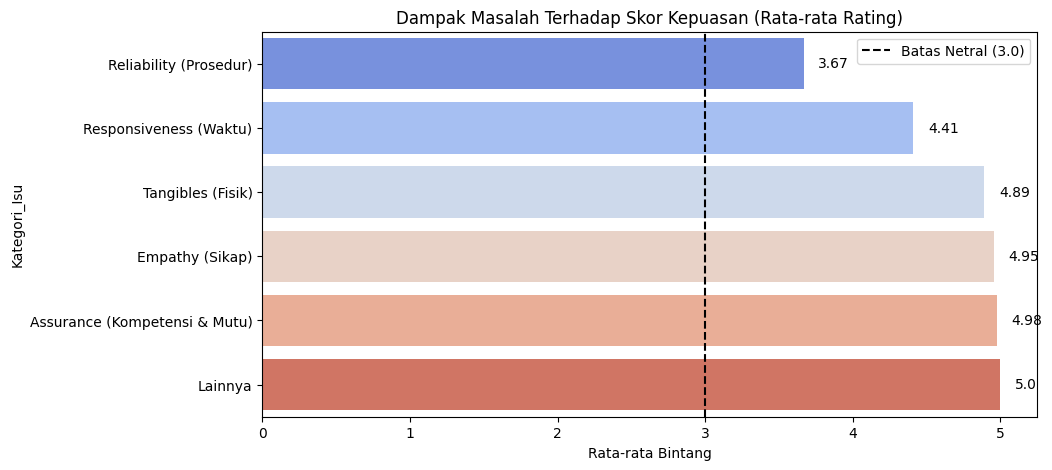

In [ ]:

# Hitung rata-rata rating untuk setiap Kategori Masalah
avg_rating = df.groupby('Kategori_Isu')['Rating'].mean().sort_values()

# Buat Plot
plt.figure(figsize=(10, 5))
plot = sns.barplot(x=avg_rating.values, y=avg_rating.index, palette='coolwarm')

plt.title('Dampak Masalah Terhadap Skor Kepuasan (Rata-rata Rating)')
plt.xlabel('Rata-rata Bintang')
plt.axvline(x=3, color='black', linestyle='--', label='Batas Netral (3.0)') # Garis batas
plt.legend()

# Tampilkan angkanya di ujung batang
for i, v in enumerate(avg_rating.values):
    plot.text(v + 0.1, i, str(round(v, 2)), color='black', va='center')

plt.show()

In [ ]:
def deteksi_isu_servqual_final(teks):
    teks = str(teks).lower()

    # 1. TANGIBLES (Fisik & Fasilitas)
    # Tambahan: parkiran, wc, ruangan, bed, panas, gerah, kumuh, sarana
    keyword_tangibles = ['parkir', 'toilet', 'wc', 'kamar', 'ruang', 'gedung', 'bangunan',
                         'ac', 'panas', 'gerah', 'dingin', 'kotor', 'bersih', 'bau', 'wangi',
                         'kursi', 'rusak', 'kumuh', 'sempit', 'fasilitas', 'kantin', 'mushola',
                         'sarana', 'prasarana', 'nyaman']
    if any(x in teks for x in keyword_tangibles):
        return 'Tangibles (Fisik)'

    # 2. RESPONSIVENESS (Waktu & Kecepatan)
    # Tambahan: ngantri, nunggu, lelet, jam, seharian, lemot
    keyword_responsiveness = ['antri', 'ngantri', 'lama', 'lambat', 'nunggu', 'menunggu',
                              'lelet', 'lemot', 'jam', 'telat', 'ngaret', 'cepat',
                              'segera', 'ditinggal', 'seharian', 'buru']
    if any(x in teks for x in keyword_responsiveness):
        return 'Responsiveness (Waktu)'

    # 3. EMPATHY (Sikap & Pelayanan Orang)
    # Tambahan: security, satpam, dr (singkatan), care, melayani
    keyword_empathy = ['ramah', 'sopan', 'senyum', 'judes', 'galak', 'kasar',
                       'bentak', 'marah', 'cuek', 'sabar', 'suster', 'perawat', 'bidan',
                       'satpam', 'security', 'sekuriti', 'petugas', 'staf', 'pelayanan', 'melayani']
    if any(x in teks for x in keyword_empathy):
        return 'Empathy (Sikap)'

    # 4. ASSURANCE (Kompetensi & Jaminan Mutu) -> UPDATE BESAR DISINI
    # Tambahan: baik, bagus, terbaik, memuaskan, mantap, good
    keyword_assurance = ['dokter', 'dr.', 'dr ', 'ahli', 'profesional', 'kompeten',
                         'jelas', 'paham', 'mengerti', 'tindakan', 'operasi', 'usg',
                         'rontgen', 'lab', 'cek', 'periksa',
                         'bagus', 'mantap', 'terbaik', 'baik', 'ok', 'oke', 'good',
                         'memuaskan', 'puas', 'kecewa', 'parah', 'buruk', 'recom', 'bintang']
    if any(x in teks for x in keyword_assurance):
        return 'Assurance (Kompetensi & Mutu)'

    # 5. RELIABILITY (Prosedur & Admin)
    # Tambahan: ribet, susah, berbelit, daftar, aplikasi, obat
    keyword_reliability = ['obat', 'resep', 'apotek', 'farmasi', 'daftar', 'admin',
                           'registrasi', 'loket', 'bpjs', 'kis', 'bayar', 'biaya', 'kasir',
                           'rujukan', 'sistem', 'aplikasi', 'online', 'jkn', 'ribet',
                           'susah', 'mudah', 'gampang', 'berbelit', 'prosedur', 'alur']
    if any(x in teks for x in keyword_reliability):
        return 'Reliability (Prosedur)'

    return 'Lainnya'

# Terapkan ulang
df['Kategori_Isu'] = df['Review'].apply(deteksi_isu_servqual_final)

# Cek hasilnya lagi
print("--- Distibusi Terbaru (Setelah Update) ---")
print(df['Kategori_Isu'].value_counts())

--- Distibusi Terbaru (Setelah Update) ---
Kategori_Isu
Empathy (Sikap)                  155
Tangibles (Fisik)                 73
Responsiveness (Waktu)            44
Assurance (Kompetensi & Mutu)     41
Lainnya                            7
Reliability (Prosedur)             3
Name: count, dtype: int64


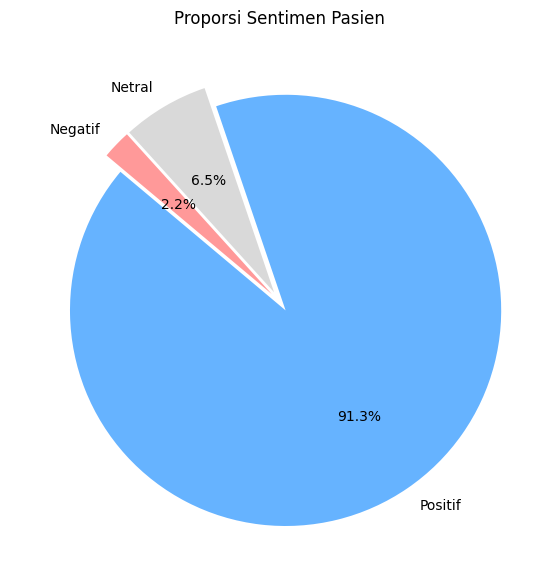

In [ ]:

import matplotlib.pyplot as plt

# Pastikan kolom Sentimen sudah ada (dari kode cek_sentimen_final sebelumnya)
# Hitung jumlah tiap sentimen
sentimen_counts = df['Sentimen'].value_counts()

# Warna standar: Hijau (Positif), Merah (Negatif), Abu (Netral)
warna_map = {'Positif': '#66b3ff', 'Negatif': '#ff9999', 'Netral': '#d9d9d9'}
warna = [warna_map.get(x, '#d9d9d9') for x in sentimen_counts.index]

plt.figure(figsize=(7, 7))
# autopct untuk menampilkan persen
plt.pie(sentimen_counts, labels=sentimen_counts.index, autopct='%1.1f%%',
        startangle=140, colors=warna, explode=(0.05, 0.05, 0.05))

plt.title('Proporsi Sentimen Pasien')
plt.show()

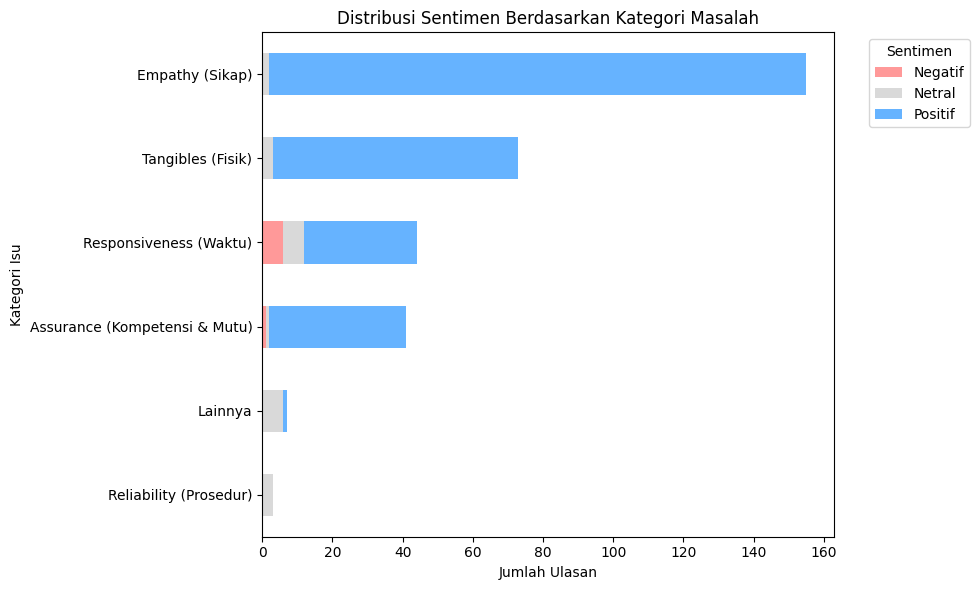

In [ ]:
import seaborn as sns

# Buat tabel silang (Crosstab) antara Kategori Isu dan Sentimen
ct = pd.crosstab(df['Kategori_Isu'], df['Sentimen'])

# Urutkan berdasarkan total ulasan terbanyak
ct['Total'] = ct.sum(axis=1)
ct = ct.sort_values('Total', ascending=True).drop(columns='Total')

# Plot Stacked Bar Chart
ax = ct.plot(kind='barh', stacked=True, figsize=(10, 6),
             color=[warna_map.get(x, '#333') for x in ct.columns])

plt.title('Distribusi Sentimen Berdasarkan Kategori Masalah')
plt.xlabel('Jumlah Ulasan')
plt.ylabel('Kategori Isu')
plt.legend(title='Sentimen', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()